In [1]:
import os
import re
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            # Replace all occurrences of double slashes with a single slash
                            _fname = re.sub(r'/+', '/', fname[0])
                            files.append(_fname)
    return files

In [ ]:
# LASSO case dates
# start_dates = ["20181129"]
# start_dates = ["20181204"]
# start_dates = ["20181205"]
# start_dates = ["20190122"]
start_dates = ["20190123"]
# start_dates = ["20190125"]
# start_dates = ["20190129"]
# start_dates = ["20190208"]

# start_dates = [
#     "20181129", 
#     "20181204",
#     "20181205", 
#     # "20181219", 
#     "20190122", 
#     "20190123",
#     "20190125",
#     "20190129",
#     "20190208",
# ]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'domain_timeseries_cellstats_'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/'

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2_15min')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3_15min')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4_15min')
print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of stats files (D4): {len(files_d4)}')
files_d2, files_d3, files_d4

Number of stats files (D2): 2
Number of stats files (D3): 2
Number of stats files (D4): 2


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20190208/eda03/base/d2_15min/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20190208/eda08/base/d2_15min/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc'],
 ['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda03/base/d3_15min/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda08/base/d3_15min/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc'],
 ['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda03/base/d4_15min/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20190208/eda08/base/d4_15min/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc'])

In [412]:
dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/'
basename_obs = 'domain_timeseries_cellstats_'

statsfiles_obs = []
for idate in start_dates:
    statsfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{basename_obs}{idate}*nc')))

print(f'Number of cases (OBS): {len(statsfiles_obs)}')
statsfiles_obs

Number of cases (OBS): 1


['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc']

In [413]:
dir_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/'
basename_obs = 'domain_timeseries_cellstats_'

statsfiles_obs25 = []
for idate in start_dates:
    statsfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{basename_obs}{idate}*nc')))

print(f'Number of cases (OBS 2.5km): {len(statsfiles_obs25)}')
statsfiles_obs25

Number of cases (OBS 2.5km): 1


['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/domain_timeseries_cellstats_20190208.1200_20190209.0000.nc']

## Limit time window for analysis in each case
### The window is determined manually by examining cold pool animations to exclude periods when significant cold pools develop

In [414]:
# +2 h
case_hours_dict_d2 = {
    '20181129-gefs00': (12.0, 21.5),
    '20181129-gefs03': (12.0, 22.0),
    '20181129-gefs09': (12.0, 20.5),
    '20181129-gefs18': (12.0, 20.5),
    '20181204-gefs18': (12.0, 19.5),
    '20181204-gefs19': (12.0, 21.0),
    '20181205-gefs01': (12.0, 20.0),
    '20181219-eda09': (12.0, 19.0),
    '20190122-gefs01': (12.0, 23.5),
    '20190122-gefs18': (12.0, 22.25),
    '20190123-eda05': (12.0, 18.0),
    '20190123-gefs18': (12.0, 19.5),
    '20190125-eda07': (12.0, 20.5),
    '20190125-gefs11': (12.0, 20.5),
    '20190129-eda09': (12.0, 20.0),
    '20190129-gefs11': (12.0, 19.5),
    '20190208-eda03': (12.0, 21.5),
    '20190208-eda08': (12.0, 21.75),
}

In [415]:
# +1 h
case_hours_dict_d3 = {
    '20181129-gefs00': (12.0, 20.5),
    '20181129-gefs03': (12.0, 21.0),
    '20181129-gefs09': (12.0, 20.0),
    '20181129-gefs18': (12.0, 20.0),
    '20181204-gefs18': (12.0, 18.5),
    '20181204-gefs19': (12.0, 20.0),
    '20181205-gefs01': (12.0, 19.0),
    '20181219-eda09': (12.0, 18.0),
    '20190122-gefs01': (12.0, 22.5),
    '20190122-gefs18': (12.0, 21.5),
    '20190123-eda05': (12.0, 17.0),
    '20190123-gefs18': (12.0, 18.5),
    '20190125-eda07': (12.0, 19.5),
    '20190125-gefs11': (12.0, 19.5),
    '20190129-eda09': (12.0, 19.5),
    '20190129-gefs11': (12.0, 19.25),
    '20190208-eda03': (12.0, 21.0),
    '20190208-eda08': (12.0, 21.0),
}

In [416]:
# Assume same cold pool development times in D4 as in D3
case_hours_dict_d4 = case_hours_dict_d3

## Read and combine data files

In [417]:
def get_casename(in_file):
    """
    Get case date, ensemble member, and config from full filename
    """
    # Example file name with file directory:
    # .../meso//20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc
    caseconfig = (in_file).split(os.path.sep)[-4]
    ensmember = (in_file).split(os.path.sep)[-5]
    casedate = (in_file).split(os.path.sep)[-6]
    return caseconfig, ensmember, casedate

In [418]:
def read_combine(tfiles, domain):
    """
    Read files and combine multiple DataSets.
        
    Args:
        tfiles: list
            List of input files.
        domain: string
            String denoting the domain.
        
    Returns:
        ds: Xarray DataSet
            Combined Xarray DataSet.
    """
    
    # Make lists for the DataSets
    case_list = []
    dst_list = []

    # Loop over the number of files
    for ii in range(len(tfiles)):
        tfile = tfiles[ii]
        caseconfig, ensmember, casedate = get_casename(tfile)
        # Make casename (date-ensmember) and look up hours
        casename = f"{casedate}-{ensmember}-{domain}"
        casename_upper = casename.upper()  # Convert to upper case
        print(casename_upper)
        case_list.append(casename_upper)
        # Get hours range for the case
        # hours_range = case_hours_dict[casename]
        # print(casename, hours_range)
        # print(tfile, wfile, efile)

    # # Concetenante subsetted DataSets
    # dst = xr.concat(dst_list, dim='case')

    # Open all datasets
    datasets = [xr.open_dataset(f) for f in tfiles]

    # Concatenate along a new 'case' dimension
    combined_ds = xr.concat(datasets, dim=xr.Variable('case', case_list))
    
    # Close file handles (if using `xr.open_dataset` instead of `xr.open_mfdataset`)
    for ds in datasets:
        ds.close()

    return combined_ds

In [419]:
# Read D2 data
ds_d2 = read_combine(files_d2, domain='d2')
ds_d2

20190208-EDA03-D2
20190208-EDA08-D2


<xarray.Dataset> Size: 6kB
Dimensions:             (case: 2, time: 48, quantile: 3)
Coordinates:
  * time                (time) datetime64[ns] 384B 2019-02-08T12:15:00 ... 20...
  * quantile            (quantile) float64 24B 0.25 0.5 0.75
  * case                (case) <U17 136B '20190208-EDA03-D2' '20190208-EDA08-D2'
Data variables:
    echotop10_mean      (case, time) float32 384B nan nan ... 3.05e+03 2.375e+03
    tb_mean             (case, time) float32 384B nan nan nan ... 289.5 292.1
    echotop10_quantile  (case, quantile, time) float32 1kB nan nan ... 2.5e+03
    tb_quantile         (case, quantile, time) float32 1kB nan nan ... 293.0
    cellarea_mean       (case, time) float32 384B nan nan nan ... 68.75 56.25
    cellarea_quantile   (case, quantile, time) float32 1kB nan nan ... 56.25
    ncells              (case, time) float32 384B 0.0 0.0 0.0 ... 3.0 3.0 1.0
Attributes:
    Title:        Domain cell statistics time-series
    startdate:    20190208.1200
    enddate:      20190209.0000
    ensmember:    eda03
    domain:       d2
    Contact:      Zhe Feng: zhe.feng@pnnl.gov
    Institution:  Pacific Northwest National Laboratory
    created on:   Mon Feb  3 22:35:20 2025

In [420]:
# Read D3 data
ds_d3 = read_combine(files_d3, domain='d3')
# ds_d3

20190208-EDA03-D3
20190208-EDA08-D3


In [421]:
# Read D4 data
ds_d4 = read_combine(files_d4, domain='d4')
# ds_d4

20190208-EDA03-D4
20190208-EDA08-D4


In [422]:
# Read OBS data
ds_obs = xr.open_dataset(statsfiles_obs[0])
ds_obs

<xarray.Dataset> Size: 2kB
Dimensions:             (time: 30, quantile: 3)
Coordinates:
  * time                (time) datetime64[ns] 240B 2019-02-08T12:00:03 ... 20...
  * quantile            (quantile) float64 24B 0.25 0.5 0.75
Data variables:
    echotop10_mean      (time) float32 120B ...
    tb_mean             (time) float32 120B ...
    echotop10_quantile  (quantile, time) float32 360B ...
    tb_quantile         (quantile, time) float32 360B ...
    cellarea_mean       (time) float32 120B ...
    cellarea_quantile   (quantile, time) float32 360B ...
    ncells              (time) float32 120B ...
Attributes:
    Title:        Domain cell statistics time-series
    startdate:    20190208.1200
    enddate:      20190209.0000
    ensmember:    None
    domain:       None
    Contact:      Zhe Feng: zhe.feng@pnnl.gov
    Institution:  Pacific Northwest National Laboratory
    created on:   Mon Feb  3 19:51:14 2025

In [423]:
# Read OBS 2.5km data
ds_obs25 = xr.open_dataset(statsfiles_obs25[0])
ds_obs25

<xarray.Dataset> Size: 2kB
Dimensions:             (time: 30, quantile: 3)
Coordinates:
  * time                (time) datetime64[ns] 240B 2019-02-08T12:00:03 ... 20...
  * quantile            (quantile) float64 24B 0.25 0.5 0.75
Data variables:
    echotop10_mean      (time) float32 120B ...
    tb_mean             (time) float32 120B ...
    echotop10_quantile  (quantile, time) float32 360B ...
    tb_quantile         (quantile, time) float32 360B ...
    cellarea_mean       (time) float32 120B ...
    cellarea_quantile   (quantile, time) float32 360B ...
    ncells              (time) float32 120B ...
Attributes:
    Title:        Domain cell statistics time-series
    startdate:    20190208.1200
    enddate:      20190209.0000
    ensmember:    None
    domain:       None
    Contact:      Zhe Feng: zhe.feng@pnnl.gov
    Institution:  Pacific Northwest National Laboratory
    created on:   Tue Feb  4 23:16:16 2025

In [424]:
# ds_obs.tb_mean.plot.line(color='k', lw=3, label='OBS')
# ds_d4.tb_mean.plot.line(x='time')
# plt.ylim(295,230)

In [425]:
# ds_obs.tb_quantile.sel(quantile=0.5).plot.line(color='k', lw=3, label='OBS')
# ds_d4.tb_quantile.sel(quantile=0.5).plot.line(x='time')
# plt.ylim(295,210)

In [426]:
# ds_obs.echotop10_quantile.sel(quantile=0.5).plot.line(color='k', lw=3, label='OBS')
# ds_d4.echotop10_quantile.sel(quantile=0.5).plot.line(x='time')
# # plt.ylim(295,230)

In [427]:
# Convert cell area to equivalent diameter
diam_avg_obs = 2 * np.sqrt(ds_obs.cellarea_mean)
diam_qnt_obs = 2 * np.sqrt(ds_obs.cellarea_quantile)
diam_avg_obs25 = 2 * np.sqrt(ds_obs25.cellarea_mean)
diam_qnt_obs25 = 2 * np.sqrt(ds_obs25.cellarea_quantile)
diam_avg_d2 = 2 * np.sqrt(ds_d2.cellarea_mean)
diam_qnt_d2 = 2 * np.sqrt(ds_d2.cellarea_quantile)
diam_avg_d3 = 2 * np.sqrt(ds_d3.cellarea_mean)
diam_qnt_d3 = 2 * np.sqrt(ds_d3.cellarea_quantile)
diam_avg_d4 = 2 * np.sqrt(ds_d4.cellarea_mean)
diam_qnt_d4 = 2 * np.sqrt(ds_d4.cellarea_quantile)

# Convert ETH units from [m] to [km]
eth10_qnt_obs = ds_obs.echotop10_quantile / 1000
eth10_qnt_obs25 = ds_obs25.echotop10_quantile / 1000
eth10_qnt_d2 = ds_d2.echotop10_quantile / 1000
eth10_qnt_d3 = ds_d3.echotop10_quantile / 1000
eth10_qnt_d4 = ds_d4.echotop10_quantile / 1000

tb_qnt_obs = ds_obs.tb_quantile
tb_qnt_obs25 = ds_obs25.tb_quantile
tb_qnt_d2 = ds_d2.tb_quantile
tb_qnt_d3 = ds_d3.tb_quantile
tb_qnt_d4 = ds_d4.tb_quantile

ncells_obs = ds_obs.ncells
ncells_obs25 = ds_obs25.ncells
ncells_d2 = ds_d2.ncells
ncells_d3 = ds_d3.ncells
ncells_d4 = ds_d4.ncells

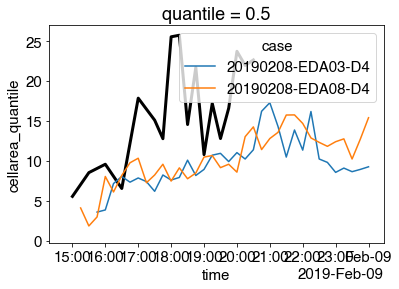

In [428]:
diam_qnt_obs.sel(quantile=0.5).plot.line(color='k', lw=3, label='OBS')
diam_qnt_d4.sel(quantile=0.5).plot.line(x='time')

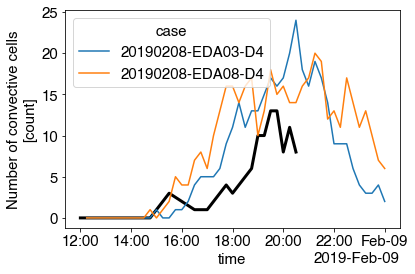

In [429]:
ds_obs.ncells.plot(color='k', lw=3, label='OBS')
ds_d4.ncells.plot.line(x='time')

In [430]:
# case_date = start_dates[0]
# ensmember = 'GEFS09'
# icase = f"{case_date}-{ensmember}"

# fig, axes = plt.subplots(1, 3, figsize=(16,4), dpi=100)
# ax0 = axes[0]
# ax0b = ax0.twinx()

# ncells_hourly_obs = ds_obs.ncells.coarsen(time=4, boundary='trim').sum()
# bar_times = ncells_hourly_obs['time'].values
# bar_values = ncells_hourly_obs.values
# ax0b.bar(bar_times, bar_values, color='silver', alpha=0.7, width=0.03, label='Number of Cells', zorder=1)

# q25 = diam_qnt_obs.sel(quantile=0.25)
# q50 = diam_qnt_obs.sel(quantile=0.5)
# q75 = diam_qnt_obs.sel(quantile=0.75)
# ax0.fill_between(q50['time'], q25, q75, facecolor='gray', alpha=0.3, label='Interquartile Range (0.25-0.75)', zorder=2)  # Shaded area
# diam_qnt_obs.sel(quantile=0.5).plot.line(color='k', lw=3, label='OBS', ax=ax0, zorder=3)
# diam_qnt_d2.sel(quantile=0.5, case=f'{icase}-D2').plot.line(color='dodgerblue', x='time', ax=ax0, zorder=3)
# diam_qnt_d3.sel(quantile=0.5, case=f'{icase}-D3').plot.line(color='seagreen', x='time', ax=ax0, zorder=3)
# diam_qnt_d4.sel(quantile=0.5, case=f'{icase}-D4').plot.line(color='darkviolet', x='time', ax=ax0, zorder=3)

# # Make ax1 frame invisible so that the bars on ax2 are visible behind it
# ax0.set_frame_on(False)

# ncell_ymax = ncells_hourly_obs.max().item()
# ax0b.set_ylim(0,ncell_ymax*4)
# # ax0b.set_ylabel('Number of Cells')

# # Ensure the primary y-axis (ax0) is above the bars visually
# ax0.set_zorder(ax0b.get_zorder() + 1)

# ax1 = axes[1]
# q25 = ds_obs.echotop10_quantile.sel(quantile=0.25)
# q50 = ds_obs.echotop10_quantile.sel(quantile=0.5)
# q75 = ds_obs.echotop10_quantile.sel(quantile=0.75)
# ds_obs.echotop10_quantile.sel(quantile=0.5).plot.line(color='k', lw=3, label='OBS', ax=ax1)
# ds_d2.echotop10_quantile.sel(quantile=0.5, case=f'{icase}-D2').plot.line(color='dodgerblue', x='time', ax=ax1)
# ds_d3.echotop10_quantile.sel(quantile=0.5, case=f'{icase}-D3').plot.line(color='seagreen', x='time', ax=ax1)
# ds_d4.echotop10_quantile.sel(quantile=0.5, case=f'{icase}-D4').plot.line(color='darkviolet', x='time', ax=ax1)
# ax1.fill_between(q50['time'], q25, q75, facecolor='gray', alpha=0.3, label='Interquartile Range (0.25-0.75)')  # Shaded area

# ax2 = axes[2]
# q25 = ds_obs.tb_quantile.sel(quantile=0.25)
# q50 = ds_obs.tb_quantile.sel(quantile=0.5)
# q75 = ds_obs.tb_quantile.sel(quantile=0.75)
# ds_obs.tb_quantile.sel(quantile=0.5).plot.line(color='k', lw=3, label='OBS', ax=ax2)
# ds_d2.tb_quantile.sel(quantile=0.5, case=f'{icase}-D2').plot.line(color='dodgerblue', x='time', ax=ax2)
# ds_d3.tb_quantile.sel(quantile=0.5, case=f'{icase}-D3').plot.line(color='seagreen', x='time', ax=ax2)
# ds_d4.tb_quantile.sel(quantile=0.5, case=f'{icase}-D4').plot.line(color='darkviolet', x='time', ax=ax2)
# ax2.fill_between(q50['time'], q25, q75, facecolor='gray', alpha=0.3, label='Interquartile Range (0.25-0.75)')  # Shaded area
# ax2.set_ylim(300,210)

# fig.tight_layout()

In [431]:
ncells_hourly_obs = ds_obs.ncells.coarsen(time=4, boundary='trim').sum()
# ncells_hourly_obs
ncells_hourly_obs['time'].values
# ncells_hourly_obs.plot.bar(ax=ax, x='time', label='Hourly Sum', color='lightblue', alpha=0.7, width=0.03)

array(['2019-02-08T12:22:33.000000000', '2019-02-08T13:22:33.000000000',
       '2019-02-08T14:22:33.000000000', '2019-02-08T15:45:03.000000000',
       '2019-02-08T17:33:48.250000000', '2019-02-08T18:37:33.000000000',
       '2019-02-08T19:37:33.000000000'], dtype='datetime64[ns]')

In [432]:
case_hours_dict_d2

{'20181129-gefs00': (12.0, 21.5),
 '20181129-gefs03': (12.0, 22.0),
 '20181129-gefs09': (12.0, 20.5),
 '20181129-gefs18': (12.0, 20.5),
 '20181204-gefs18': (12.0, 19.5),
 '20181204-gefs19': (12.0, 21.0),
 '20181205-gefs01': (12.0, 20.0),
 '20181219-eda09': (12.0, 19.0),
 '20190122-gefs01': (12.0, 23.5),
 '20190122-gefs18': (12.0, 22.25),
 '20190123-eda05': (12.0, 18.0),
 '20190123-gefs18': (12.0, 19.5),
 '20190125-eda07': (12.0, 20.5),
 '20190125-gefs11': (12.0, 20.5),
 '20190129-eda09': (12.0, 20.0),
 '20190129-gefs11': (12.0, 19.5),
 '20190208-eda03': (12.0, 21.5),
 '20190208-eda08': (12.0, 21.75)}

## Function to plot all ensemble members for each resolution

In [433]:
def plot_allens(nrow, ncol, da_lines, da_shade, time_shade=None,
             wspace=None, hspace=None, top=None, suptitle=None, suptitle_y=None, invert_yaxis=None,
             xlims=None, ylims=None, xlabels=None, ylabels=None, legend_fs=None, legend_show=None,
             titles=None, fontsize=None, figsize=None, figname=None, dpi=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    time_fmt = mdates.DateFormatter('%H')
    
    lw = 2
    lcolors = {'o':'k', 'e0':'tab:blue', 'e1':'tab:orange', 'e2':'tab:green', 'e3':'tab:red'}
    scolors = {'d2':'lightblue', 'd3':'palegreen', 'd4':'plum'}
    t_shade_alpha = 0.3

    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace, top=top)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if variable is None
            da_l = da_lines[row][col]
            if (da_l is not None):
                da_s = da_shade[row][col]
                # Setup two columns (left: plot, right: colorbar)
                # gss = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[row,col], height_ratios=[1], width_ratios=[1,0.02], wspace=0.02, hspace=0.)
                ax = plt.subplot(gs[row,col])
                ax.plot(da_l['o'].time, da_l['o'].values, color=lcolors['o'], lw=lw*2, zorder=2, label='OBS')
                nlines = da_l['e'].sizes['case']
                for ll in range(nlines):
                    l_case = da_l['e'].isel(case=ll)
                    l_label = l_case.case.item().split('-')[1]
                    ax.plot(da_l['e'].time, l_case, color=lcolors[f'e{ll}'], zorder=2, label=l_label)
                if (da_s is not None):
                    ax.fill_between(da_s['lo'].time, da_s['lo'], da_s['hi'], facecolor='gray', alpha=0.5, zorder=1)  # Shaded area
                
                if (legend_show[row][col]): ax.legend(loc='best', fontsize=legend_fs)
                # Axes, labels
                ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
                ax.xaxis.set_major_formatter(time_fmt)
                ax.grid(ls=':')
                if (xlims is not None): ax.set_xlim(xlims[0],xlims[1])
                if (ylims is not None): ax.set_ylim(ylims[row][col][0],ylims[row][col][1])
                if (invert_yaxis is not None):
                    if (invert_yaxis[row][col]): ax.invert_yaxis()
                if (titles is not None): ax.set_title(titles[row][col], loc='left')
                if (xlabels is not None): ax.set_xlabel(xlabels[row][col])
                if (ylabels is not None): ax.set_ylabel(ylabels[row][col])
                if (time_shade is not None):
                    t_s = time_shade[row][col]
                    ax.axvspan(xmin=t_s['d2'], xmax=xlims[1], facecolor=scolors['d2'], alpha=t_shade_alpha, zorder=3)
                    ax.axvspan(xmin=t_s['d3'], xmax=xlims[1], facecolor=scolors['d3'], alpha=t_shade_alpha, zorder=3)
                    ax.axvspan(xmin=t_s['d4'], xmax=xlims[1], facecolor=scolors['d4'], alpha=t_shade_alpha, zorder=3)
                    
    if (suptitle is not None): fig.suptitle(suptitle, y=suptitle_y, weight='bold')
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

nrow: 4, ncol: 3
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/domain_timeseries_cellstats_20190208_AllEnsemble.png


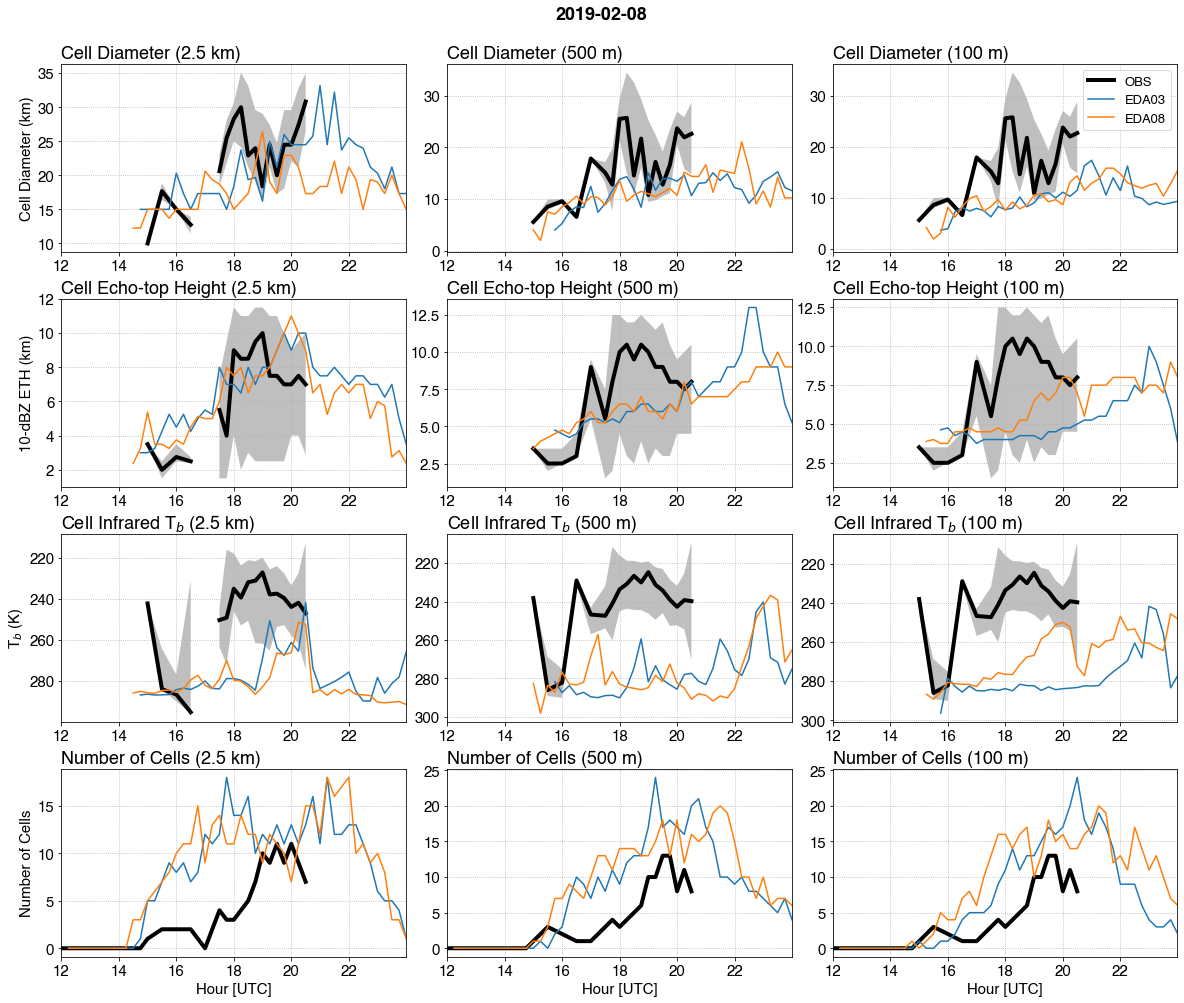

In [434]:
case_date = start_dates[0]

da_lines = [
    [{'o':diam_qnt_obs25.sel(quantile=0.5), 'e':diam_qnt_d2.sel(quantile=0.5)},
     {'o':diam_qnt_obs.sel(quantile=0.5), 'e':diam_qnt_d3.sel(quantile=0.5)},
     {'o':diam_qnt_obs.sel(quantile=0.5), 'e':diam_qnt_d4.sel(quantile=0.5)},],
    [{'o':eth10_qnt_obs25.sel(quantile=0.5), 'e':eth10_qnt_d2.sel(quantile=0.5)},
     {'o':eth10_qnt_obs.sel(quantile=0.5), 'e':eth10_qnt_d3.sel(quantile=0.5)},
     {'o':eth10_qnt_obs.sel(quantile=0.5), 'e':eth10_qnt_d4.sel(quantile=0.5)},],
    [{'o':tb_qnt_obs25.sel(quantile=0.5), 'e':tb_qnt_d2.sel(quantile=0.5)},
     {'o':tb_qnt_obs.sel(quantile=0.5), 'e':tb_qnt_d3.sel(quantile=0.5)},
     {'o':tb_qnt_obs.sel(quantile=0.5), 'e':tb_qnt_d4.sel(quantile=0.5)},],
    [{'o':ncells_obs25, 'e':ncells_d2},
     {'o':ncells_obs, 'e':ncells_d3},
     {'o':ncells_obs, 'e':ncells_d4},],
]
nrow = len(da_lines)
ncol = len(da_lines[0])
print(f"nrow: {nrow}, ncol: {ncol}")

diam_iqr = {'lo':diam_qnt_obs.sel(quantile=0.25), 'hi':diam_qnt_obs.sel(quantile=0.75)}
eth10_iqr = {'lo':eth10_qnt_obs.sel(quantile=0.25), 'hi':eth10_qnt_obs.sel(quantile=0.75)}
tb_iqr = {'lo':tb_qnt_obs.sel(quantile=0.25), 'hi':tb_qnt_obs.sel(quantile=0.75)}

diam_iqr25 = {'lo':diam_qnt_obs25.sel(quantile=0.25), 'hi':diam_qnt_obs25.sel(quantile=0.75)}
eth10_iqr25 = {'lo':eth10_qnt_obs25.sel(quantile=0.25), 'hi':eth10_qnt_obs25.sel(quantile=0.75)}
tb_iqr25 = {'lo':tb_qnt_obs25.sel(quantile=0.25), 'hi':tb_qnt_obs25.sel(quantile=0.75)}

da_shade = [
    [diam_iqr25, diam_iqr, diam_iqr],
    [eth10_iqr25, eth10_iqr, eth10_iqr],
    [tb_iqr25, tb_iqr, tb_iqr],
    [None, None, None],
]
# # Time period shading for cold pools
# t_shade = {'d2':cp_time_s_d2, 'd3':cp_time_s_d3, 'd4':cp_time_s_d4}
# time_shade = [
#     [t_shade]*ncol,
#     [t_shade]*ncol,
#     [t_shade]*ncol,
# ]

time_s = pd.to_datetime(f"{case_date}T12", format='%Y%m%dT%H')
time_e = time_s.replace(hour=23, minute=59)
date_fmt = time_s.strftime('%Y-%m-%d')
xlims = [time_s, time_e]
# ylims = [[(0,40)]*ncol, [(2,16)]*ncol, [(290,190)]*ncol, [(0,50)]*ncol]
ylims = None
invert_yaxis = [[False]*ncol, [False]*ncol, [True]*ncol, [False]*ncol]
xlabels = [[f'']*ncol, [f'']*ncol, [f'']*ncol, [f'Hour [UTC]']*ncol, ]
ylabels = [['Cell Diameter (km)','',''], ['10-dBZ ETH (km)','',''], ['T$_{b}$ (K)','',''], ['Number of Cells','','']]
titles = [['Cell Diameter (2.5 km)', 'Cell Diameter (500 m)', 'Cell Diameter (100 m)', ],
          ['Cell Echo-top Height (2.5 km)', 'Cell Echo-top Height (500 m)', 'Cell Echo-top Height (100 m)'],
          ['Cell Infrared T$_{b}$ (2.5 km)', 'Cell Infrared T$_{b}$ (500 m)', 'Cell Infrared T$_{b}$ (100 m)'],
          ['Number of Cells (2.5 km)', 'Number of Cells (500 m)', 'Number of Cells (100 m)'],]
suptitle = f"{date_fmt}"
suptitle_y = 0.95

legend_show = [[False, False, True],[False]*ncol,[False]*ncol,[False]*ncol]
legend_fs = 13
fontsize = 15
figsize = (20,16)
wspace = 0.12
hspace = 0.25
figname = f'{figdir}domain_timeseries_cellstats_{case_date}_AllEnsemble.png'
print(figname)

fig = plot_allens(nrow, ncol, da_lines, da_shade, time_shade=None, xlims=xlims, xlabels=xlabels, ylims=ylims, ylabels=ylabels, 
               titles=titles, suptitle=suptitle, suptitle_y=suptitle_y, invert_yaxis=invert_yaxis,
               wspace=wspace, hspace=hspace, top=0.9,
               legend_fs=legend_fs, legend_show=legend_show,
               fontsize=fontsize, figsize=figsize, figname=figname)

In [435]:
start_dates

['20190208']

## Make time stamps for cold pool periods

In [436]:
case_date = start_dates[0]
if case_date == '2019-01-23': ensmember = 'GEFS18'  # 2019-01-23
if case_date == '2018-11-29': ensmember = 'GEFS09'  # 2018-11-29

# Get analysis hour end window for the case
cp_key = f"{case_date}-{ensmember.lower()}"
cp_hour_d2 = case_hours_dict_d2[cp_key][1]
cp_hour_d3 = case_hours_dict_d3[cp_key][1]
cp_hour_d4 = case_hours_dict_d4[cp_key][1]
# Calculate hours and minutes from the fractional hour
hours_d2 = int(cp_hour_d2)
minutes_d2 = int((cp_hour_d2 - hours_d2) * 60)
hours_d3 = int(cp_hour_d3)
minutes_d3 = int((cp_hour_d3 - hours_d3) * 60)
hours_d4 = int(cp_hour_d4)
minutes_d4 = int((cp_hour_d4 - hours_d4) * 60)

# Get start hour
time_s = pd.to_datetime(f"{case_date}T12", format='%Y%m%dT%H')
cp_time_s_d2 = time_s.replace(hour=hours_d2, minute=minutes_d2)
cp_time_s_d3 = time_s.replace(hour=hours_d3, minute=minutes_d3)
cp_time_s_d4 = time_s.replace(hour=hours_d4, minute=minutes_d4)
cp_time_s_d2, cp_time_s_d3, cp_time_s_d4

KeyError: '20190208-gefs18'

## Function to plot 1 ensemble member across multiple resolutions

In [ ]:
def plot_allres(nrow, ncol, da_lines, da_shade, time_shade=None,
             wspace=None, hspace=None, top=None, suptitle=None, suptitle_y=None, invert_yaxis=None,
             xlims=None, ylims=None, xlabels=None, ylabels=None, legend_fs=None, legend_show=None, legend_ncol=None,
             titles=None, fontsize=None, figsize=None, figname=None, dpi=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    time_fmt = mdates.DateFormatter('%H')
    
    lw = 2
    lcolors = {'o':'k', 'o25':'dimgray', 'd2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    scolors = {'d2':'lightblue', 'd3':'palegreen', 'd4':'plum'}
    t_shade_alpha = 0.3

    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace, top=top)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if variable is None
            da_l = da_lines[row][col]
            if (da_l is not None):
                da_s = da_shade[row][col]
                # Setup two columns (left: plot, right: colorbar)
                gss = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row,col], height_ratios=[1], width_ratios=[1,0.02], wspace=0.02, hspace=0.)
                ax = plt.subplot(gss[0])
                ax.plot(da_l['o'].time, da_l['o'].values, color=lcolors['o'], lw=lw*2, zorder=2, label='OBS 500 m')
                ax.plot(da_l['o25'].time, da_l['o25'].values, color=lcolors['o25'], lw=lw*2, ls='-', zorder=2, label='OBS 2.5 km')
                ax.plot(da_l['d2'].time, da_l['d2'].values, color=lcolors['d2'], lw=lw, zorder=2, label='2.5 km')
                ax.plot(da_l['d3'].time, da_l['d3'].values, color=lcolors['d3'], lw=lw, zorder=2, label='500 m')
                ax.plot(da_l['d4'].time, da_l['d4'].values, color=lcolors['d4'], lw=lw, zorder=2, label='100 m')
                if (da_s is not None):
                    ax.fill_between(da_s['lo'].time, da_s['lo'], da_s['hi'], facecolor='gray', alpha=0.5, zorder=1)  # Shaded area
                
                if (legend_show[row][col]): ax.legend(loc='best', fontsize=legend_fs, ncol=legend_ncol)
                # Axes, labels
                ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
                ax.xaxis.set_major_formatter(time_fmt)
                ax.grid(ls=':')
                if (xlims is not None): ax.set_xlim(xlims[0],xlims[1])
                if (ylims is not None): ax.set_ylim(ylims[row][col][0],ylims[row][col][1])
                if (invert_yaxis is not None):
                    if (invert_yaxis[row][col]): ax.invert_yaxis()
                if (titles is not None): ax.set_title(titles[row][col], loc='left')
                if (xlabels is not None): ax.set_xlabel(xlabels[row][col])
                if (ylabels is not None): ax.set_ylabel(ylabels[row][col])
                if (time_shade is not None):
                    t_s = time_shade[row][col]
                    ax.axvspan(xmin=t_s['d2'], xmax=xlims[1], facecolor=scolors['d2'], alpha=t_shade_alpha, zorder=3)
                    ax.axvspan(xmin=t_s['d3'], xmax=xlims[1], facecolor=scolors['d3'], alpha=t_shade_alpha, zorder=3)
                    ax.axvspan(xmin=t_s['d4'], xmax=xlims[1], facecolor=scolors['d4'], alpha=t_shade_alpha, zorder=3)
                    
    if (suptitle is not None): fig.suptitle(suptitle, y=suptitle_y, weight='bold')
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

nrow: 1, ncol: 4
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/domain_timeseries_cellstats_20190123_GEFS18.png


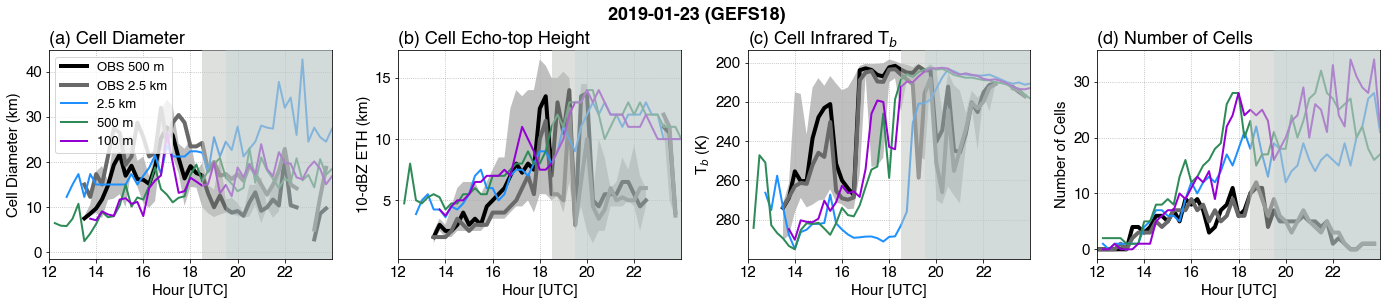

In [ ]:
case_date = start_dates[0]
icase = f"{case_date}-{ensmember}"

da_lines = [
    [{'o':diam_qnt_obs.sel(quantile=0.5), 
      'o25': diam_qnt_obs25.sel(quantile=0.5),
      'd2':diam_qnt_d2.sel(quantile=0.5, case=f'{icase}-D2'), 
      'd3':diam_qnt_d3.sel(quantile=0.5, case=f'{icase}-D3'),
      'd4':diam_qnt_d4.sel(quantile=0.5, case=f'{icase}-D4')},
     {'o':eth10_qnt_obs.sel(quantile=0.5), 
      'o25': eth10_qnt_obs25.sel(quantile=0.5),
      'd2':eth10_qnt_d2.sel(quantile=0.5, case=f'{icase}-D2'), 
      'd3':eth10_qnt_d3.sel(quantile=0.5, case=f'{icase}-D3'),
      'd4':eth10_qnt_d4.sel(quantile=0.5, case=f'{icase}-D4')},
     {'o':tb_qnt_obs.sel(quantile=0.5), 
      'o25': tb_qnt_obs25.sel(quantile=0.5),
      'd2':tb_qnt_d2.sel(quantile=0.5, case=f'{icase}-D2'), 
      'd3':tb_qnt_d3.sel(quantile=0.5, case=f'{icase}-D3'),
      'd4':tb_qnt_d4.sel(quantile=0.5, case=f'{icase}-D4')},
     {'o':ncells_obs, 
      'o25': ncells_obs25,
      'd2':ncells_d2.sel(case=f'{icase}-D2'), 
      'd3':ncells_d3.sel(case=f'{icase}-D3'),
      'd4':ncells_d4.sel(case=f'{icase}-D4')}]
]
nrow = len(da_lines)
ncol = len(da_lines[0])
print(f"nrow: {nrow}, ncol: {ncol}")

da_shade = [
    [{'lo':diam_qnt_obs.sel(quantile=0.25), 'hi':diam_qnt_obs.sel(quantile=0.75)},
     {'lo':eth10_qnt_obs.sel(quantile=0.25), 'hi':eth10_qnt_obs.sel(quantile=0.75)},
     {'lo':tb_qnt_obs.sel(quantile=0.25), 'hi':tb_qnt_obs.sel(quantile=0.75)},
     None,]
]
# Time period shading for cold pools
t_shade = {'d2':cp_time_s_d2, 'd3':cp_time_s_d3, 'd4':cp_time_s_d4}
time_shade = [
    [t_shade, t_shade, t_shade, t_shade],
]

time_s = pd.to_datetime(f"{case_date}T12", format='%Y%m%dT%H')
time_e = time_s.replace(hour=23, minute=59)
date_fmt = time_s.strftime('%Y-%m-%d')
xlims = [time_s, time_e]
# ylims = [[(0,40), (0,18), (290,190), (0,40)]]
ylims = None
invert_yaxis = [[False, False, True, False]]
xlabels = [[f'Hour [UTC]']*ncol]
ylabels = [['Cell Diameter (km)', '10-dBZ ETH (km)', 'T$_{b}$ (K)', 'Number of Cells']]
titles = [['(a) Cell Diameter', '(b) Cell Echo-top Height', '(c) Cell Infrared T$_{b}$', '(d) Number of Cells']]
suptitle = f"{date_fmt} ({ensmember})"
suptitle_y = 0.999
# suptitle_y = 0.001

legend_show = [[True, False, False, False]]
legend_fs = 13
legend_ncol = 1
fontsize = 15
figsize = (24,4)
wspace = 0.2
figname = f'{figdir}domain_timeseries_cellstats_{case_date}_{ensmember}.png'
print(figname)

fig = plot_allres(nrow, ncol, da_lines, da_shade, time_shade=time_shade, xlims=xlims, xlabels=xlabels, ylims=ylims, ylabels=ylabels, 
               titles=titles, suptitle=suptitle, suptitle_y=suptitle_y, invert_yaxis=invert_yaxis,
               wspace=wspace, top=0.85,
               legend_fs=legend_fs, legend_show=legend_show, legend_ncol=legend_ncol,
               fontsize=fontsize, figsize=figsize, figname=figname)